# TD3 — Prétraitement EEG : des signaux connus aux signaux du dataset CL-Drive

## Objectifs pédagogiques

Ce TD est consacré au **prétraitement des signaux EEG**. Il prépare directement le projet final sur l'estimation de la charge cognitive du conducteur à partir du dataset CL-Drive.

À la fin du TD, vous devez être capables de :

1. expliquer pourquoi un signal EEG doit être prétraité ;
2. comprendre le rôle d'un filtre passe-bande ;
3. comprendre le rôle d'un filtre notch ;
4. tester une chaîne de prétraitement sur des signaux synthétiques connus ;
5. appliquer la même logique à des signaux EEG du dataset ;
6. comparer les signaux avant et après traitement dans le domaine temporel et fréquentiel ;
7. formaliser une fonction de prétraitement EEG réutilisable dans le projet.

Dans le papier CL-Drive, l'EEG est acquis avec un casque Muse à 4 canaux, échantillonné à **256 Hz**. Le prétraitement EEG indiqué par les auteurs utilise un filtre passe-bande Butterworth d'ordre 2 entre **0.4 Hz et 75 Hz**, puis un filtre notch à **60 Hz** avec facteur de qualité **30**.

## 1. Pourquoi prétraiter un signal EEG ?

Un signal EEG brut contient l'activité électrique mesurée au niveau du cuir chevelu, mais aussi des perturbations :

- dérive lente de la ligne de base ;
- bruit secteur 50 Hz ou 60 Hz ;
- bruit haute fréquence ;
- artefacts.

Le prétraitement ne sert pas à embellir le signal. Il sert à produire un signal plus exploitable pour la segmentation, l'extraction de features et la classification.

Chaîne visée :

$$
\text{EEG brut} \rightarrow \text{gestion des valeurs manquantes} \rightarrow \text{passe-bande} \rightarrow \text{notch} \rightarrow \text{EEG prétraité}
$$

### Question 1

Citer au moins trois sources d'artefacts dans un signal EEG brut.

### Réponse 

Trois grandes familles :

- **Physiologiques** : clignements et mouvements oculaires (EOG, basse fréquence et forte amplitude, surtout sur AF7/AF8), contractions musculaires (EMG, haute fréquence), activité cardiaque (ECG, visible près de TP9/TP10).
- **Instrumentales** : dérive lente de la ligne de base (< 0.5 Hz), variations d'impédance peau–électrode, sauts ou NaN (Not a Number) dus à un mauvais contact.
- **Environnementales** : bruit secteur (50 Hz en Europe, **60 Hz pour CL-Drive**), parasites électromagnétiques, vibrations du véhicule.

À chaque famille sa parade : passe-bande contre la dérive et le bruit large bande, notch contre la raie secteur.

## 2. Tester le prétraitement sur des signaux connus

Avant d'appliquer une chaîne de traitement à un EEG réel, il est utile de la tester sur un signal synthétique dont on connaît exactement le contenu fréquentiel.

On construira un signal contenant :

$$
x(t) = x_{lent}(t) + x_{alpha}(t) + x_{beta}(t) + x_{secteur}(t) + b(t)
$$

avec :

- une dérive lente à 0.2 Hz ;
- une composante alpha à 10 Hz ;
- une composante beta à 25 Hz ;
- une composante de bruit secteur à 50 Hz ou 60 Hz ;
- un bruit aléatoire.

Si le traitement est correct, la dérive lente et le bruit secteur doivent être fortement réduits, tandis que les composantes utiles doivent rester visibles.

### Question 2

Pourquoi commencer par un signal synthétique avant un signal EEG réel ?

### Réponse 

Sur un signal synthétique, on sait *exactement* ce qui doit disparaître (dérive 0.2 Hz, raie 60 Hz) et ce qui doit rester (alpha 10 Hz, beta 25 Hz).

Trois bénéfices :

- **Vérifier le code** : un bug de normalisation par Nyquist ou d'ordre du filtre se voit immédiatement sur la PSD.
- **Séparer les causes d'erreur** : sur EEG réel, une PSD bizarre peut venir du sujet, de l'électrode ou du code ; sur synthétique, seul le code est en cause.
- **Étalonner les paramètres** (ordre, coupures, Q) avant de les appliquer aux 21 participants de CL-Drive.

En somme : on valide l'outil sur le connu avant d'interpréter l'inconnu.

### Activité 1 — Générer un signal synthétique

Consignes méthodologiques :

1. créer un axe temporel de 20 secondes avec `fs = 256 Hz` ;
2. ajouter une sinusoïde lente à 0.2 Hz ;
3. ajouter une sinusoïde à 10 Hz ;
4. ajouter une sinusoïde à 25 Hz ;
5. ajouter une sinusoïde à 60 Hz ;
6. ajouter un bruit gaussien ;
7. tracer le signal temporel ;
8. calculer la PSD avec `scipy.signal.welch`.

Fonctions utiles : `np.arange`, `np.sin`, `np.random.normal`, `plt.plot`, `welch`.

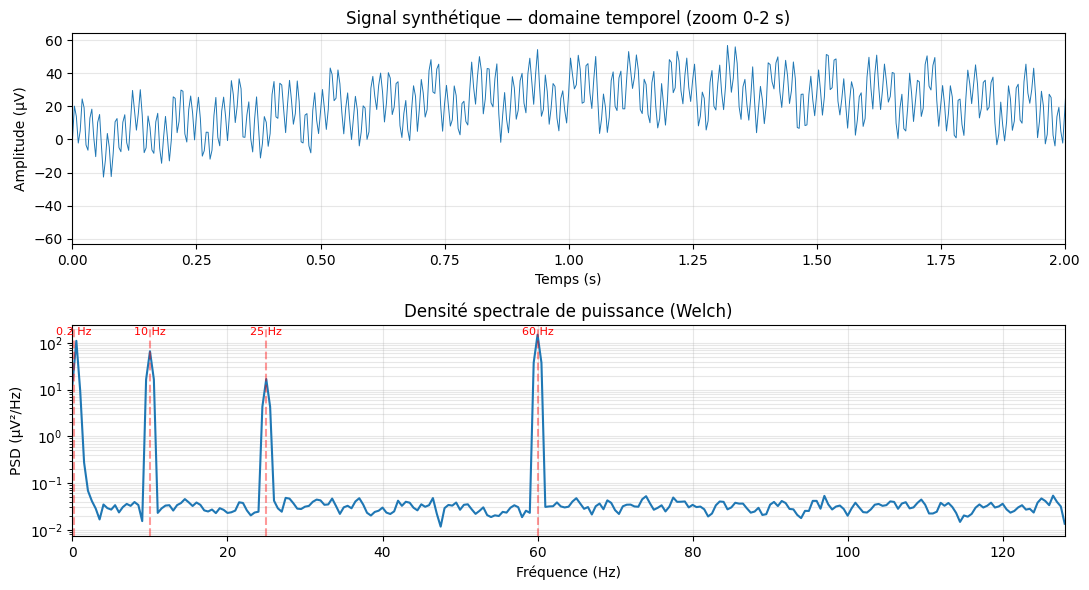

Nombre d'échantillons : 5120
Durée                 : 20 s
Fréquence de Nyquist  : 128.0 Hz


In [1]:
# Activité 1 — Implémenter ici la génération du signal synthétique.
# Suivre les étapes décrites dans la cellule précédente.
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# 1. Axe temporel
fs = 256                       # fréquence d'échantillonnage (Hz)
duration = 20                  # durée (s)
t = np.arange(0, duration, 1 / fs)

# 2-5. Composantes sinusoïdales
x_lent    = 30.0 * np.sin(2 * np.pi * 0.2 * t)   # dérive lente (0.2 Hz)
x_alpha   = 10.0 * np.sin(2 * np.pi * 10  * t)   # alpha (10 Hz)
x_beta    =  5.0 * np.sin(2 * np.pi * 25  * t)   # beta (25 Hz)
x_secteur = 15.0 * np.sin(2 * np.pi * 60  * t)   # secteur (60 Hz)

# 6. Bruit gaussien
rng = np.random.default_rng(seed=0)
bruit = rng.normal(loc=0.0, scale=2.0, size=t.shape)

# Signal synthétique complet
x = x_lent + x_alpha + x_beta + x_secteur + bruit

# 7. Tracé temporel (zoom 2 s pour la lisibilité)
fig, axes = plt.subplots(2, 1, figsize=(11, 6))

axes[0].plot(t, x, lw=0.7)
axes[0].set_xlim(0, 2)
axes[0].set_xlabel("Temps (s)")
axes[0].set_ylabel("Amplitude (µV)")
axes[0].set_title("Signal synthétique — domaine temporel (zoom 0-2 s)")
axes[0].grid(True, alpha=0.3)

# 8. PSD via Welch
f, Pxx = welch(x, fs=fs, nperseg=2 * fs)

axes[1].semilogy(f, Pxx)
for f0, label in [(0.2, "0.2 Hz"), (10, "10 Hz"), (25, "25 Hz"), (60, "60 Hz")]:
    axes[1].axvline(f0, color="red", ls="--", alpha=0.4)
    axes[1].text(f0, Pxx.max(), label, color="red", fontsize=8, ha="center")
axes[1].set_xlim(0, fs / 2)
axes[1].set_xlabel("Fréquence (Hz)")
axes[1].set_ylabel("PSD (µV²/Hz)")
axes[1].set_title("Densité spectrale de puissance (Welch)")
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Nombre d'échantillons : {x.size}")
print(f"Durée                 : {duration} s")
print(f"Fréquence de Nyquist  : {fs / 2} Hz")

Conclusion

Le signal synthétique est valide : il contient bien les 4 composantes attendues + bruit blanc, dans les bonnes proportions. Tu peux passer à l'Activité 2 : le passe-bande devra écraser le pic à ~0 Hz et laisser intacts les pics à 10, 25, 60 Hz. Le pic 60 Hz, lui, ne disparaîtra qu'à l'Activité 3 (notch).

## 3. Filtre passe-bande Butterworth

Un filtre passe-bande conserve les fréquences situées dans une bande choisie et atténue les autres.

Dans CL-Drive, la bande EEG retenue est :

$$
0.4 \leq f \leq 75 \quad \text{Hz}
$$

Pour un signal échantillonné à $ f_s $, la fréquence de Nyquist vaut :

$$
f_N = \frac{f_s}{2}
$$

Les fréquences de coupure doivent être normalisées :

$$
W_{low}=\frac{f_{low}}{f_N}, \qquad W_{high}=\frac{f_{high}}{f_N}
$$

Fonctions utiles :

- `scipy.signal.butter` pour concevoir le filtre ;
- `scipy.signal.sosfiltfilt` pour filtrer sans déphasage notable ;
- `scipy.signal.welch` pour vérifier l'effet fréquentiel.

### Question 3

Pourquoi utiliser `filtfilt` ou `sosfiltfilt` pour une analyse hors ligne ?

### Réponse 

Parce qu'un filtre causal classique introduit un **déphasage** : les pics du signal sont décalés dans le temps, ce qui fausse la latence des événements EEG (P300, marqueurs de stimuli, segmentation en fenêtres).

`filtfilt` / `sosfiltfilt` filtrent **deux fois**, à l'endroit puis à l'envers :

- **déphasage net = 0** → les événements gardent leur position temporelle ;
- **ordre effectif doublé** → atténuation plus franche pour le même ordre nominal ;
- **incompatible temps réel** (il faut connaître le signal entier), donc réservé à l'analyse *hors ligne* — exactement notre cas dans CL-Drive.

`sosfiltfilt` est préféré à `filtfilt` pour les ordres élevés : la forme **SOS** (Second-Order Sections) est numériquement plus stable que la forme `(b, a)`.

### Question 4

Calculer la fréquence de Nyquist pour `fs = 256 Hz`.

### Réponse 

$$
f_N = \frac{f_s}{2} = \frac{256}{2} = \boxed{128\ \text{Hz}}
$$

C'est la fréquence maximale représentable sans repliement (théorème de Shannon). Toute composante au-delà de 128 Hz serait *aliasée*, c'est-à-dire repliée vers les basses fréquences et indissociable d'un signal utile.

Conséquence pratique pour CL-Drive : `highcut = 75 Hz` est bien inférieur à 128 Hz, donc valide ; et le notch à 60 Hz, lui aussi sous Nyquist, est correctement résolu.

### Activité 2 — Algorithme du filtre passe-bande

Écrire une fonction de filtre passe-bande.

Algorithme :

1. fixer `lowcut = 0.4` ;
2. fixer `highcut = 75` ;
3. fixer `order = 2` ;
4. calculer `nyquist = fs / 2` ;
5. normaliser les fréquences ;
6. créer le filtre avec `butter(..., output="sos")` ;
7. appliquer le filtre avec `sosfiltfilt` ;
8. comparer signal brut et signal filtré.

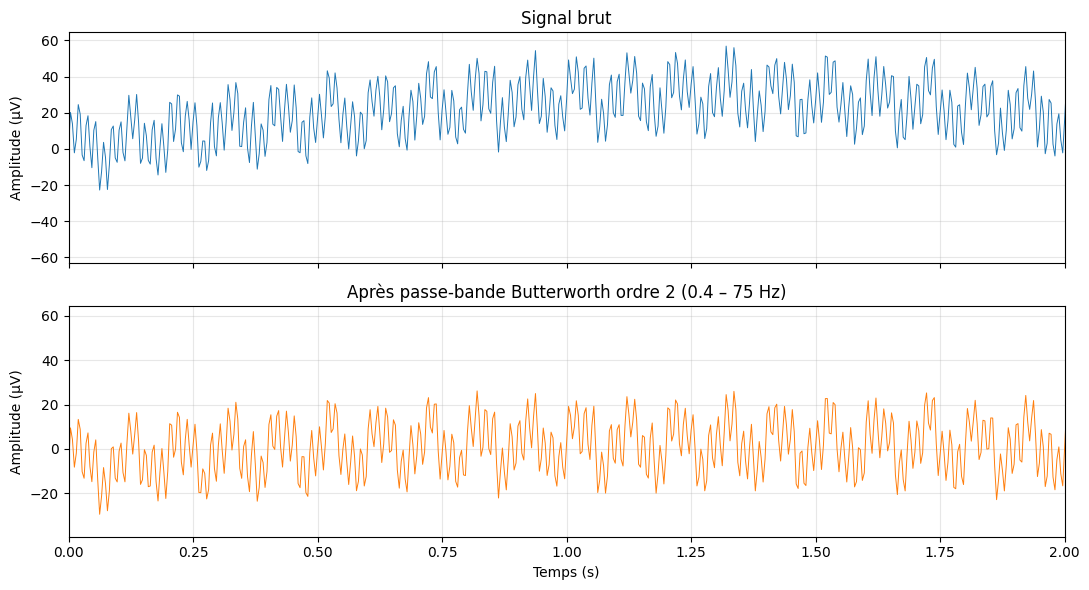

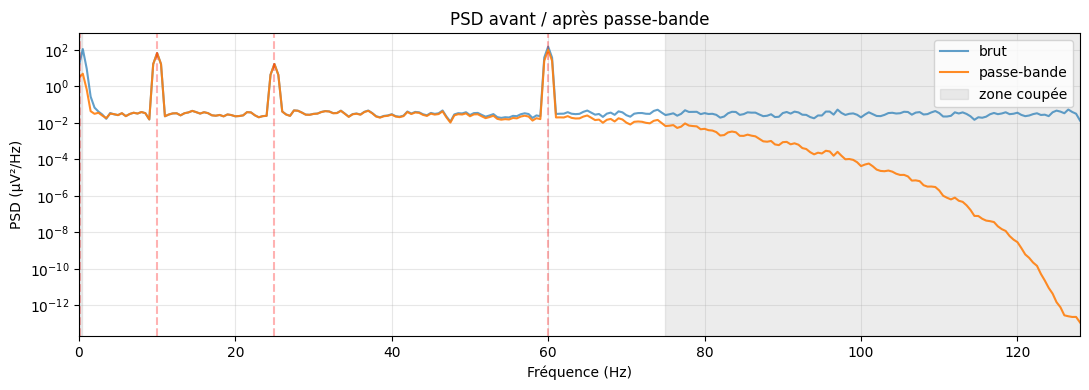

Écart-type brut   :  25.09 µV
Écart-type filtré :  12.55 µV   (dérive 0.2 Hz supprimée)


In [2]:
# Activité 2 — Filtre passe-bande Butterworth (0.4 – 75 Hz)
from scipy.signal import butter, sosfiltfilt, welch

def bandpass_filter(signal, fs, lowcut=0.4, highcut=75.0, order=2):
    """Filtre passe-bande Butterworth zéro-phase (sosfiltfilt)."""
    nyquist = fs / 2
    wn = [lowcut / nyquist, highcut / nyquist]
    sos = butter(order, wn, btype="bandpass", output="sos")
    return sosfiltfilt(sos, signal)

# Application au signal synthétique x de l'Activité 1
x_bp = bandpass_filter(x, fs=fs, lowcut=0.4, highcut=75.0, order=2)

# --- Comparaison temporelle (zoom 0–2 s) ---
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(t, x, lw=0.7)
axes[0].set_xlim(0, 2)
axes[0].set_ylabel("Amplitude (µV)")
axes[0].set_title("Signal brut")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, x_bp, lw=0.7, color="C1")
axes[1].set_xlabel("Temps (s)")
axes[1].set_ylabel("Amplitude (µV)")
axes[1].set_title("Après passe-bande Butterworth ordre 2 (0.4 – 75 Hz)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Comparaison fréquentielle ---
f, Pxx_raw = welch(x,    fs=fs, nperseg=2 * fs)
_, Pxx_bp  = welch(x_bp, fs=fs, nperseg=2 * fs)

plt.figure(figsize=(11, 4))
plt.semilogy(f, Pxx_raw, label="brut",        alpha=0.7)
plt.semilogy(f, Pxx_bp,  label="passe-bande", alpha=0.9)
for f0 in (0.2, 10, 25, 60):
    plt.axvline(f0, color="red", ls="--", alpha=0.3)
plt.axvspan(0,  0.4,    color="grey", alpha=0.15, label="zone coupée")
plt.axvspan(75, fs / 2, color="grey", alpha=0.15)
plt.xlim(0, fs / 2)
plt.xlabel("Fréquence (Hz)")
plt.ylabel("PSD (µV²/Hz)")
plt.title("PSD avant / après passe-bande")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Écart-type brut   : {x.std():6.2f} µV")
print(f"Écart-type filtré : {x_bp.std():6.2f} µV   (dérive 0.2 Hz supprimée)")

## 4. Filtre notch

Un filtre notch est contrôlé par :

- sa fréquence cible `notch_freq` ;
- son facteur de qualité `Q`.

Dans le papier, `Q = 30`.

Fonctions utiles : `scipy.signal.iirnotch`, puis `scipy.signal.filtfilt`.

### Question 5

Pourquoi CL-Drive utilise-t-il un notch à 60 Hz alors qu'en France on utilise plutôt 50 Hz ?

### Réponse 

Parce que **la fréquence du secteur dépend du pays d'acquisition**. Le réseau électrique fonctionne à **50 Hz en Europe** et à **60 Hz en Amérique du Nord**.

Le dataset CL-Drive a été collecté à **Queen's University (Kingston, Canada)** — les électrodes EEG, très sensibles, captent par couplage électromagnétique la raie du réseau local, soit **60 Hz**. C'est précisément cette fréquence que les auteurs ciblent (`notch_freq = 60`, `Q = 30`, *Section IV-A* du papier Angkan et al. 2023).

Appliquer un notch à 50 Hz sur ces données serait une double erreur : on creuserait un trou dans une bande utile (haut beta / bas gamma) **sans supprimer la pollution réelle**, qui resterait franche à 60 Hz. Règle générale : **le notch doit s'aligner sur la fréquence du secteur du lieu d'acquisition**, pas sur celle du pays de l'analyste.

### Question 6

Pourquoi ne faut-il pas appliquer automatiquement un notch sans regarder la PSD ?

### Réponse 

Trois raisons :

- **Un notch n'est jamais gratuit** : il creuse un trou étroit dans le spectre et supprime aussi le *signal cérébral* présent dans cette zone. À 60 Hz on est dans la bande **gamma (31–75 Hz)**, qui porte de l'information pertinente pour la charge cognitive. Si la raie secteur est absente, on perd de l'information utile sans aucun bénéfice.
- **La fréquence cible dépend du contexte** (50 Hz en Europe, 60 Hz en Amérique du Nord, plus éventuellement les harmoniques 100/120 Hz). Sans inspection préalable de la PSD, on risque de filtrer la mauvaise fréquence et de laisser la vraie raie intacte.
- **C'est un diagnostic matériel** : un pic 60 Hz très fort ou élargi révèle un problème en amont — mauvaise mise à la masse, impédance d'électrode trop élevée, câble d'alimentation à proximité. Le notch masque le symptôme mais ne corrige pas la cause ; il faut le voir avant de le filtrer.

**Conclusion** : on inspecte la PSD **avant** de filtrer pour confirmer la présence d'un pic franc à la bonne fréquence et juger si le notch est justifié. C'est cohérent avec la chaîne CL-Drive : *passe-bande → vérification PSD → notch* (et non l'inverse).

### Activité 3 — Algorithme du notch

1. choisir `notch_freq` ;
2. choisir `Q = 30` ;
3. créer le filtre avec `iirnotch` ;
4. appliquer `filtfilt` ;
5. comparer les PSD avant/après ;
6. vérifier que le pic à 60 Hz diminue.

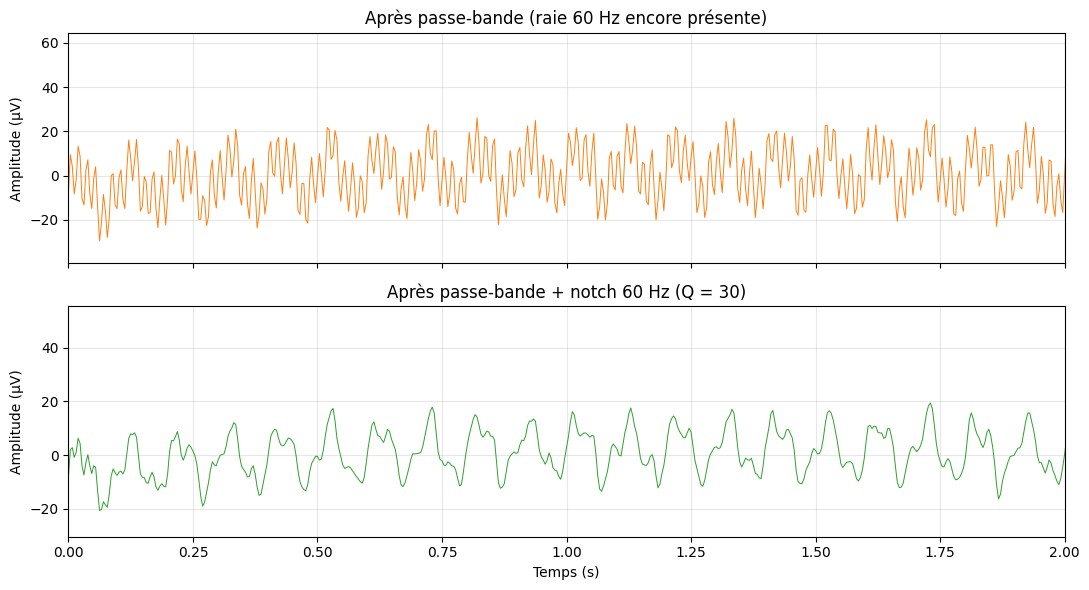

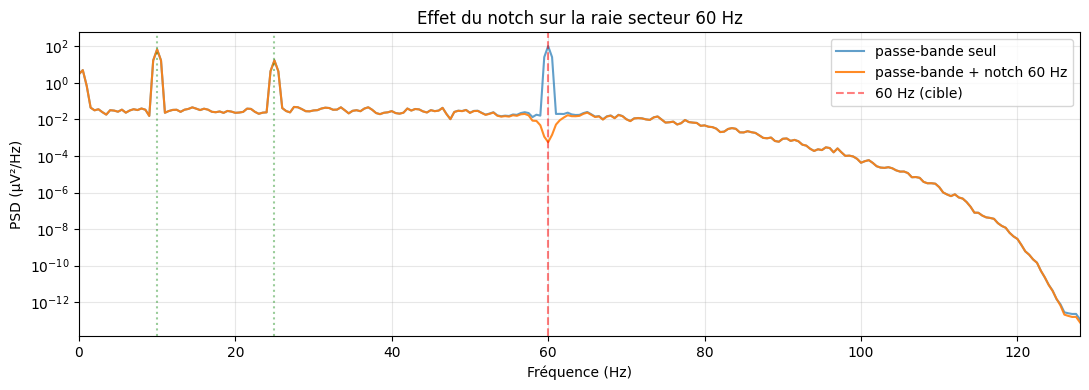

PSD à 60 Hz avant notch : 1.008e+02 µV²/Hz
PSD à 60 Hz après notch : 5.667e-04 µV²/Hz
Atténuation à 60 Hz     : -52.5 dB
Écart-type avant notch  :  12.55 µV
Écart-type après notch  :   9.06 µV   (raie 60 Hz supprimée)


In [3]:
# Activité 3 — Filtre notch (suppression de la raie secteur 60 Hz)
from scipy.signal import iirnotch, filtfilt

def notch_filter(signal, fs, notch_freq=60.0, Q=30.0):
    """Filtre notch IIR zéro-phase (filtfilt) — paramètres CL-Drive : f0=60 Hz, Q=30."""
    b, a = iirnotch(w0=notch_freq, Q=Q, fs=fs)
    return filtfilt(b, a, signal)

# Application APRÈS le passe-bande (chaîne CL-Drive : bandpass → notch)
x_notched = notch_filter(x_bp, fs=fs, notch_freq=60.0, Q=30.0)

# --- Comparaison temporelle (zoom 0-2 s) ---
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(t, x_bp, lw=0.7, color="C1")
axes[0].set_xlim(0, 2)
axes[0].set_ylabel("Amplitude (µV)")
axes[0].set_title("Après passe-bande (raie 60 Hz encore présente)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, x_notched, lw=0.7, color="C2")
axes[1].set_xlabel("Temps (s)")
axes[1].set_ylabel("Amplitude (µV)")
axes[1].set_title("Après passe-bande + notch 60 Hz (Q = 30)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Comparaison fréquentielle ---
f, Pxx_bp    = welch(x_bp,      fs=fs, nperseg=2 * fs)
_, Pxx_notch = welch(x_notched, fs=fs, nperseg=2 * fs)

plt.figure(figsize=(11, 4))
plt.semilogy(f, Pxx_bp,    label="passe-bande seul",          alpha=0.7)
plt.semilogy(f, Pxx_notch, label="passe-bande + notch 60 Hz", alpha=0.9)
plt.axvline(60, color="red", ls="--", alpha=0.5, label="60 Hz (cible)")
for f0 in (10, 25):
    plt.axvline(f0, color="green", ls=":", alpha=0.4)
plt.xlim(0, fs / 2)
plt.xlabel("Fréquence (Hz)")
plt.ylabel("PSD (µV²/Hz)")
plt.title("Effet du notch sur la raie secteur 60 Hz")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Vérification quantitative : atténuation à 60 Hz ---
idx_60 = np.argmin(np.abs(f - 60))
ratio_db = 10 * np.log10(Pxx_notch[idx_60] / Pxx_bp[idx_60])
print(f"PSD à 60 Hz avant notch : {Pxx_bp[idx_60]:.3e} µV²/Hz")
print(f"PSD à 60 Hz après notch : {Pxx_notch[idx_60]:.3e} µV²/Hz")
print(f"Atténuation à 60 Hz     : {ratio_db:.1f} dB")
print(f"Écart-type avant notch  : {x_bp.std():6.2f} µV")
print(f"Écart-type après notch  : {x_notched.std():6.2f} µV   (raie 60 Hz supprimée)")

## 5. Fonction complète de prétraitement EEG

La fonction finale doit enchaîner :

1. conversion en tableau numérique ;
2. gestion des valeurs manquantes courtes ;
3. filtrage passe-bande ;
4. filtrage notch ;
5. retour du signal prétraité.

Paramètres recommandés pour CL-Drive :

| Paramètre | Valeur |
|---|---:|
| `fs` | 256 Hz |
| `lowcut` | 0.4 Hz |
| `highcut` | 75 Hz |
| `order of filter` | 2 |
| `notch_freq` | 60 Hz |
| `quality_factor` | 30 |

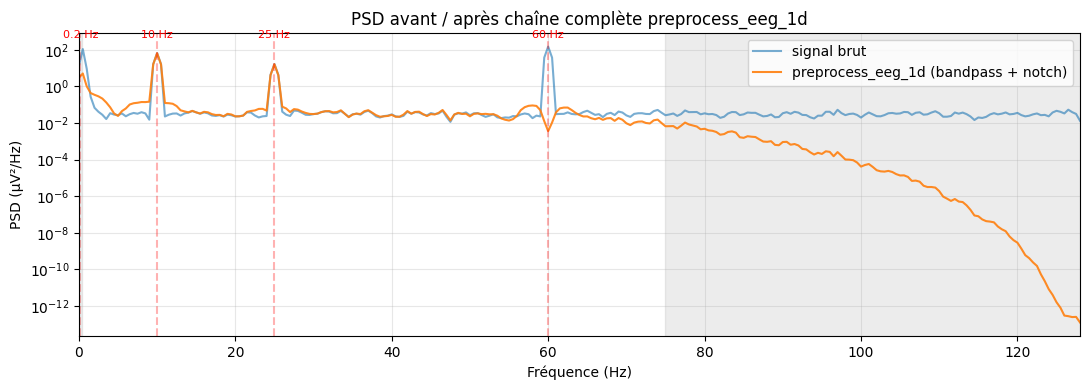

Longueur entrée / sortie : 5120 / 5120
NaN en sortie            : 0
Écart-type avant         :  25.01 µV
Écart-type après         :   9.09 µV


In [4]:
# Activité 4 — Fonction complète de prétraitement EEG 1D
# Chaîne CL-Drive (Angkan et al. 2023, Section IV-A) :
#     NaN courts → passe-bande Butterworth ordre 2 → notch 60 Hz (Q = 30)
import warnings
import pandas as pd

def preprocess_eeg_1d(signal, fs=256, lowcut=0.4, highcut=75.0, order=2,
                      notch_freq=60.0, quality_factor=30.0, max_gap_s=0.5):
    """Prétraitement d'un canal EEG (paramètres par défaut = CL-Drive).

    Étapes :
        1. conversion en tableau numérique flottant ;
        2. interpolation linéaire des trous de NaN courts (≤ max_gap_s) ;
        3. passe-bande Butterworth (filtfilt, zéro-phase) ;
        4. notch IIR à la fréquence du secteur (filtfilt) ;
        5. retour du signal prétraité, même longueur que l'entrée.

    Pour les trous longs, le papier exclut le segment du dataset. Ici, on
    remplit par 0 pour rester utilisable et on émet un warning.
    """
    # 1-2. Conversion + gestion des NaN
    x = pd.Series(np.asarray(signal, dtype=float))
    n_total = x.size

    max_gap_n = max(1, int(max_gap_s * fs))
    x = x.interpolate(method="linear", limit=max_gap_n, limit_area="inside")

    n_nan_remaining = int(x.isna().sum())
    if n_nan_remaining > 0:
        warnings.warn(
            f"{n_nan_remaining}/{n_total} NaN persistants (trous > {max_gap_s}s) "
            f"remplacés par 0. Segment à exclure idéalement (cf. Angkan 2023).",
            stacklevel=2,
        )
        x = x.fillna(0.0)

    x = x.to_numpy()

    # 3. Passe-bande (réutilise bandpass_filter de l'Activité 2)
    x = bandpass_filter(x, fs=fs, lowcut=lowcut, highcut=highcut, order=order)

    # 4. Notch (réutilise notch_filter de l'Activité 3)
    x = notch_filter(x, fs=fs, notch_freq=notch_freq, Q=quality_factor)

    return x


# --- Test sur le signal synthétique avec quelques NaN injectés ---
x_test = x.copy()
x_test[1000:1050] = np.nan   # trou court ≈ 0.2 s → doit être interpolé
x_clean = preprocess_eeg_1d(x_test, fs=fs)

assert x_clean.shape == x.shape, "longueur modifiée !"
assert not np.isnan(x_clean).any(), "des NaN subsistent en sortie !"

# --- Visualisation PSD : brut vs prétraité ---
f, Pxx_brut  = welch(x,       fs=fs, nperseg=2 * fs)
_, Pxx_clean = welch(x_clean, fs=fs, nperseg=2 * fs)

plt.figure(figsize=(11, 4))
plt.semilogy(f, Pxx_brut,  label="signal brut",                              alpha=0.6)
plt.semilogy(f, Pxx_clean, label="preprocess_eeg_1d (bandpass + notch)",     alpha=0.9)
for f0, txt in [(0.2, "0.2 Hz"), (10, "10 Hz"), (25, "25 Hz"), (60, "60 Hz")]:
    plt.axvline(f0, color="red", ls="--", alpha=0.3)
    plt.text(f0, plt.ylim()[1] * 0.5, txt, color="red", fontsize=8, ha="center")
plt.axvspan(0,  0.4,    color="grey", alpha=0.15)
plt.axvspan(75, fs / 2, color="grey", alpha=0.15)
plt.xlim(0, fs / 2)
plt.xlabel("Fréquence (Hz)")
plt.ylabel("PSD (µV²/Hz)")
plt.title("PSD avant / après chaîne complète preprocess_eeg_1d")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Longueur entrée / sortie : {x_test.size} / {x_clean.size}")
print(f"NaN en sortie            : {np.isnan(x_clean).sum()}")
print(f"Écart-type avant         : {np.nanstd(x_test):6.2f} µV")
print(f"Écart-type après         : {x_clean.std():6.2f} µV")

### Question 7

Quel effet attend-on du passe-bande sur la dérive lente à 0.2 Hz ?

### Réponse 

Une **forte atténuation**, puisque 0.2 Hz se situe sous la borne basse `lowcut = 0.4 Hz`.

Quantitativement, un Butterworth d'ordre 2 atténue à **−12 dB/octave** ; comme `sosfiltfilt` applique le filtre dans les deux sens, l'ordre effectif est doublé → **−24 dB/octave**. Entre 0.2 Hz et 0.4 Hz, il y a exactement **une octave**, donc on attend une atténuation d'environ **−24 dB** (facteur ≈ 16) sur la composante 0.2 Hz.

Conséquences observables :

- **Domaine temporel** : la ligne de base devient plate, plus de modulation lente visible sur le signal.
- **Domaine fréquentiel** : sur la PSD, le pic proche de 0 Hz s'effondre par rapport au signal brut.
- **Écart-type** : nette baisse, car la dérive lente contribuait fortement à la variance globale.

C'est l'effet recherché dans CL-Drive : éliminer les dérives électrodes/transpiration (< 0.4 Hz) tout en préservant les bandes EEG utiles (delta à partir de 0.5 Hz).

### Question 8

Quel effet attend-on du notch sur une composante à 60 Hz ?

### Réponse 

Une **atténuation très forte (typiquement −30 à −40 dB) précisément à 60 Hz**, avec un impact quasi nul sur les fréquences voisines.

Le filtre `iirnotch(f0, Q, fs)` crée une bande coupée extrêmement étroite, centrée sur `f0`. Sa largeur à −3 dB est donnée par :

$$
\text{BW} = \frac{f_0}{Q} = \frac{60}{30} = 2\ \text{Hz}
$$

Conséquences :

- La sinusoïde **exactement à 60 Hz** disparaît : sur la PSD, le pic chute de plusieurs ordres de grandeur.
- Les composantes à **58 Hz et 62 Hz** sont à peine touchées (en bordure de la bande à −3 dB).
- Les composantes utiles à **10 et 25 Hz** sont **intactes**.
- Comme on filtre avec `filtfilt`, le déphasage est nul — la position temporelle des événements est préservée.

C'est tout l'intérêt d'un `Q` élevé : plus `Q` est grand, plus le filtre est sélectif et plus on préserve le signal cérébral autour de la raie secteur. Q = 30 est le compromis retenu par CL-Drive (Angkan et al. 2023, Sec IV-A).

### Question 9

Pourquoi un highcut de 75 Hz est-il valide avec fs = 256 Hz ?

### Réponse 

Parce que **75 Hz < Nyquist = fs / 2 = 128 Hz**, donc la fréquence de coupure haute est représentable sans repliement (théorème de Shannon).

La normalisation est correcte :

$$
W_{high} = \frac{75}{128} \approx 0{,}586 \quad \in\ ]0,\ 1[
$$

Ce qui est bien dans le domaine admissible par `scipy.signal.butter` (qui exige `0 < Wn < 1`).

Trois raisons concrètes qui rendent ce choix pertinent pour CL-Drive :

- **Couverture des bandes EEG** : 75 Hz englobe delta (0.5–4), theta (4–8), alpha (8–12), beta (12–31) et **gamma (31–75 Hz)** — précisément les 5 bandes sur lesquelles le papier calcule la PSD (Section IV-B, Table V).
- **Marge confortable sous Nyquist** : 53 Hz d'écart entre highcut et 128 Hz → la transition du Butterworth se fait proprement, sans déformation près de la borne.
- **Coupure du bruit haute fréquence** : au-delà de 75 Hz se trouvent surtout les artefacts EMG (contractions musculaires) et le bruit large bande, qu'on ne veut pas voir entrer dans les features.

### Question 10

Que se passe-t-il si `highcut > fs/2` ?

### Réponse 

Le filtre est **mathématiquement impossible à construire** : on demande de couper au-dessus d'une fréquence qui n'existe pas dans le signal échantillonné.

Concrètement, en code :

$$
W_{high} = \frac{f_{high}}{f_s / 2} > 1
$$

`scipy.signal.butter` exige `0 < Wn < 1` et lève une **`ValueError`** explicite : *"Digital filter critical frequencies must be 0 < Wn < 1"*. Le filtre n'est jamais conçu, le pipeline s'arrête.

Pourquoi c'est physiquement justifié :

- **Théorème de Shannon** : toute fréquence au-dessus de Nyquist (fs/2) est repliée (*aliasing*) lors de l'échantillonnage. Filtrer au-delà reviendrait à filtrer du contenu qui a déjà été mélangé à des fréquences plus basses — ça n'a aucun sens.
- **Bonne pratique défensive** : toujours vérifier `assert highcut < fs / 2` (ou au minimum `highcut <= 0.9 * fs / 2` pour garder une marge) avant d'appeler `butter`. Utile si `fs` devient un paramètre variable, par exemple lors d'un sous-échantillonnage.

Cas typique de bug : sous-échantillonner CL-Drive de 256 Hz à **100 Hz** sans réduire `highcut = 75 Hz` → Nyquist devient 50 Hz < 75 Hz → crash. Il faudrait alors abaisser `highcut` à par ex. 40 Hz (et on perdrait la bande gamma).

## 6. Passage au signal EEG multicanal

Dans CL-Drive, les canaux EEG principaux sont AF7, AF8, TP9 et TP10.

Le prétraitement doit être appliqué **canal par canal**.

Algorithme pour un DataFrame :

1. identifier la colonne temporelle si elle existe ;
2. identifier les colonnes EEG numériques ;
3. pour chaque canal : appliquer `preprocess_eeg_1d` ;
4. conserver la colonne temporelle ;
5. retourner un DataFrame filtré.

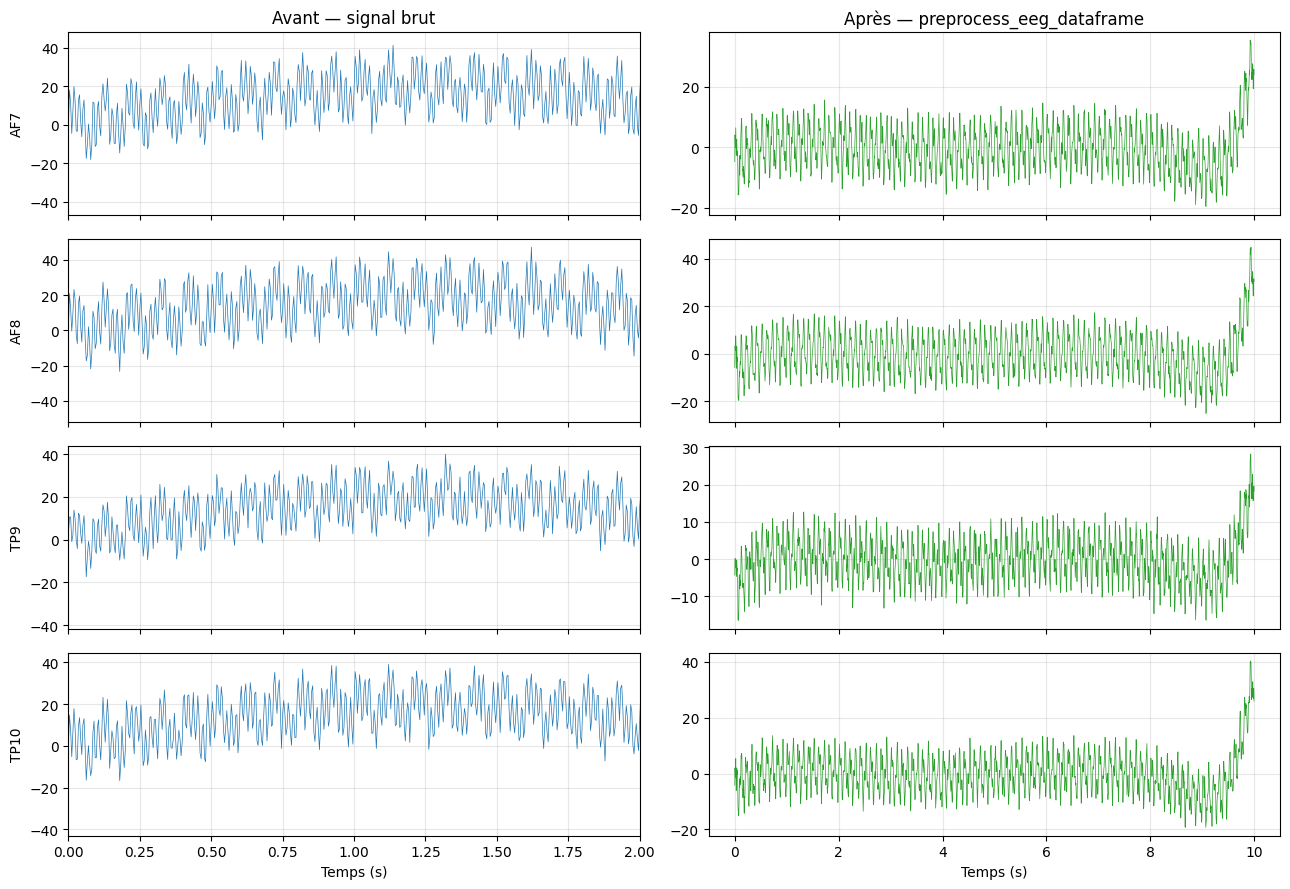

Canaux traités       : ['AF7', 'AF8', 'TP9', 'TP10']
Colonne temporelle   : 'timestamp' (préservée)
Shape entrée/sortie  : (2560, 5) / (2560, 5)
Écart-type AF7 brut  :  17.77 µV
Écart-type AF7 filtré:   7.59 µV


In [5]:
# Activité 5 — Prétraitement EEG multicanal sur DataFrame
# Canaux CL-Drive (casque Muse S, 4 électrodes) : AF7, AF8, TP9, TP10
# Chaque canal est traité indépendamment par preprocess_eeg_1d.

CL_DRIVE_CHANNELS = ["AF7", "AF8", "TP9", "TP10"]
TIME_COL_CANDIDATES = ["timestamp", "Timestamp", "TimeStamp", "time", "Time", "t"]


def preprocess_eeg_dataframe(df, fs=256, channels=None, time_col=None, **kwargs):
    """Applique preprocess_eeg_1d canal par canal sur un DataFrame EEG.

    Paramètres
    ----------
    df : pd.DataFrame
        Données EEG (≥ 1 colonne par canal, éventuellement une colonne temps).
    fs : float
        Fréquence d'échantillonnage (256 Hz pour CL-Drive).
    channels : list[str] ou None
        Canaux à traiter. Si None : détection auto des canaux CL-Drive
        (AF7, AF8, TP9, TP10), sinon repli sur toutes les colonnes numériques
        autres que la colonne temporelle.
    time_col : str ou None
        Nom de la colonne temporelle. Si None : détection auto sur les noms
        usuels (timestamp, time, …). La colonne est laissée intacte.
    **kwargs
        Transmis à preprocess_eeg_1d (lowcut, highcut, order, notch_freq, Q, …).

    Retour
    ------
    pd.DataFrame
        Copie de df avec les canaux EEG filtrés, mêmes colonnes, même ordre.
    """
    out = df.copy()

    # 1. Détection de la colonne temporelle
    if time_col is None:
        time_col = next((c for c in TIME_COL_CANDIDATES if c in out.columns), None)

    # 2. Détection des canaux EEG
    if channels is None:
        channels = [c for c in CL_DRIVE_CHANNELS if c in out.columns]
        if not channels:
            channels = [
                c for c in out.columns
                if c != time_col and pd.api.types.is_numeric_dtype(out[c])
            ]

    # 3. Application canal par canal (la colonne temps n'est jamais touchée)
    for ch in channels:
        out[ch] = preprocess_eeg_1d(out[ch].values, fs=fs, **kwargs)

    return out


# --- Démo sur un DataFrame factice à 4 canaux + colonne timestamp ---
rng_multi = np.random.default_rng(seed=1)
n_samples = fs * 10                         # 10 s à 256 Hz
t_demo = np.arange(n_samples) / fs

def _make_channel(amp_alpha, amp_60):
    return (
        20 * np.sin(2 * np.pi * 0.2 * t_demo)         # dérive lente
        + amp_alpha * np.sin(2 * np.pi * 10 * t_demo) # alpha
        + 4  * np.sin(2 * np.pi * 25 * t_demo)        # beta
        + amp_60 * np.sin(2 * np.pi * 60 * t_demo)    # secteur 60 Hz
        + rng_multi.normal(0, 2, size=n_samples)      # bruit
    )

df_demo = pd.DataFrame({
    "timestamp": t_demo,
    "AF7":  _make_channel(amp_alpha=8,  amp_60=12),
    "AF8":  _make_channel(amp_alpha=10, amp_60=14),
    "TP9":  _make_channel(amp_alpha=6,  amp_60=10),
    "TP10": _make_channel(amp_alpha=7,  amp_60=11),
})

df_clean = preprocess_eeg_dataframe(df_demo, fs=fs)

# --- Visualisation : 4 canaux avant/après (zoom 0-2 s) ---
fig, axes = plt.subplots(4, 2, figsize=(13, 9), sharex="col")
for i, ch in enumerate(CL_DRIVE_CHANNELS):
    axes[i, 0].plot(df_demo["timestamp"],  df_demo[ch],  lw=0.5)
    axes[i, 1].plot(df_clean["timestamp"], df_clean[ch], lw=0.5, color="C2")
    axes[i, 0].set_ylabel(ch)
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 1].grid(True, alpha=0.3)
axes[0, 0].set_title("Avant — signal brut")
axes[0, 1].set_title("Après — preprocess_eeg_dataframe")
axes[-1, 0].set_xlabel("Temps (s)")
axes[-1, 1].set_xlabel("Temps (s)")
axes[-1, 0].set_xlim(0, 2)
plt.tight_layout()
plt.show()

# --- Vérifications ---
assert list(df_clean.columns) == list(df_demo.columns), "colonnes modifiées !"
assert np.allclose(df_clean["timestamp"], df_demo["timestamp"]), "timestamp altéré !"
print(f"Canaux traités       : {CL_DRIVE_CHANNELS}")
print(f"Colonne temporelle   : 'timestamp' (préservée)")
print(f"Shape entrée/sortie  : {df_demo.shape} / {df_clean.shape}")
print(f"Écart-type AF7 brut  : {df_demo['AF7'].std():6.2f} µV")
print(f"Écart-type AF7 filtré: {df_clean['AF7'].std():6.2f} µV")

## 7. Application aux signaux EEG du dataset CL-Drive

Après validation sur signaux synthétiques, appliquer la chaîne à un fichier EEG réel :

1. choisir un fichier EEG CSV ;
2. charger avec `pd.read_csv` ;
3. identifier les colonnes EEG ;
4. afficher un extrait du signal brut ;
5. appliquer le prétraitement ;
6. afficher le même extrait après traitement ;
7. comparer la PSD avant/après.

Si le dataset n'est pas encore disponible localement, le notebook doit rester générique et indiquer clairement où définir le chemin.

### Activité 6 — Charger et visualiser un fichier EEG réel

Fonctions utiles :

| Objectif | Fonction |
|---|---|
| Chemin de fichier | `pathlib.Path` |
| Lecture CSV | `pd.read_csv` |
| Affichage des colonnes | `df.columns` |
| Tracé temporel | `plt.plot` |
| PSD | `welch` |

Participants disponibles : 21 → ['1030', '1105', '1106', '1241', '1271']…

Fichier        : doi-10.5683-sp3-jj2yzz\EEG\1030\eeg_data_level_5.csv
Shape          : (46546, 5)
Colonnes       : ['Timestamp', 'TP9', 'AF7', 'AF8', 'TP10']
NaN par colonne:
Timestamp    0
TP9          0
AF7          0
AF8          0
TP10         0


,Timestamp,TP9,AF7,AF8,TP10
0,120.007812,-7.812500,-21.484375,-8.300781,-32.226562
1,120.011719,-9.765625,-19.042969,-4.394531,22.949219
2,120.015625,14.160156,-3.906250,-27.832031,19.042969
3,120.019531,-11.718750,-9.277344,-26.855469,-10.742188
4,120.023438,-18.066406,-11.718750,-16.113281,-16.601562



fs inférée     : 256.00 Hz   (attendu : 256 Hz)
Durée          : 181.8 s


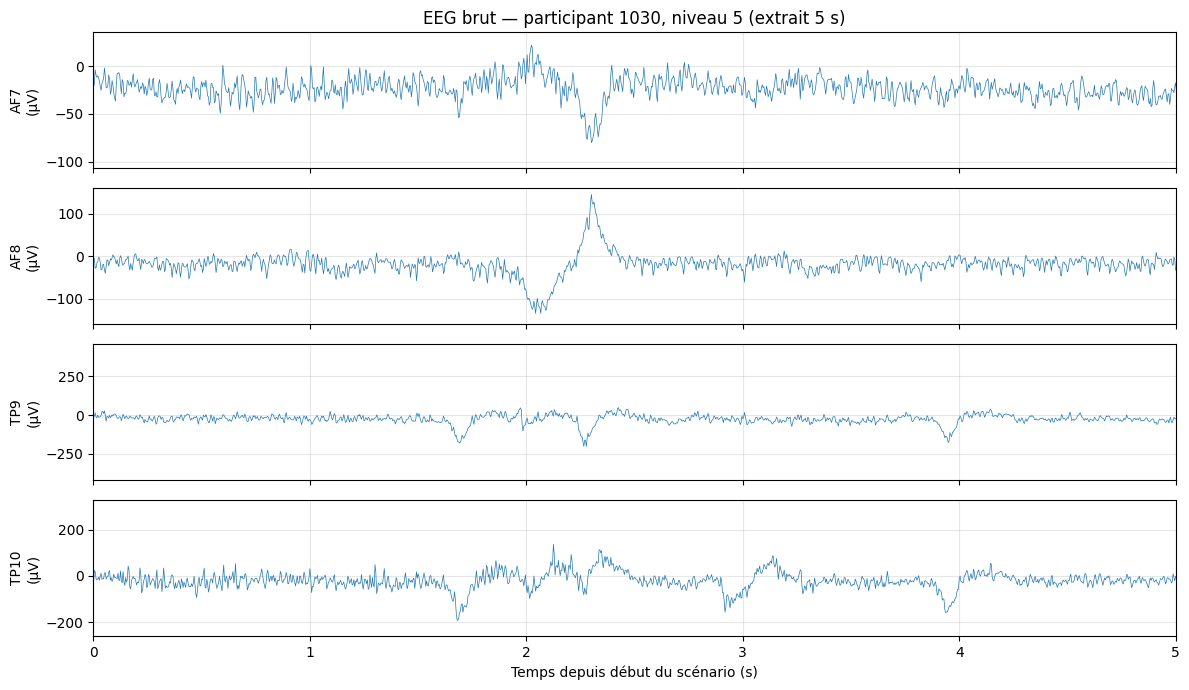

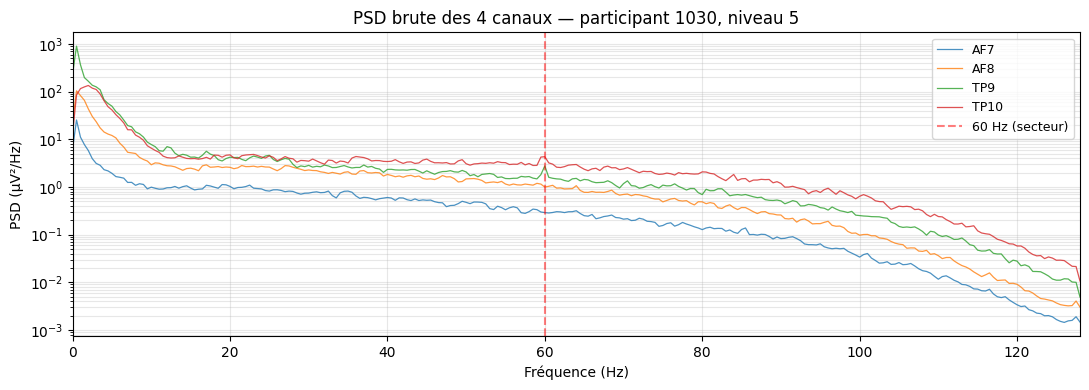

In [9]:
# Activité 6 — Charger un fichier EEG réel du dataset CL-Drive
from pathlib import Path

# Racine du dataset (adapter si besoin) — structure attendue :
#   DATASET_ROOT / EEG / <participant_id> / eeg_data_level_<N>.csv
DATASET_ROOT = Path("doi-10.5683-sp3-jj2yzz")
EEG_DIR = DATASET_ROOT / "EEG"

assert EEG_DIR.exists(), (
    f"Dossier EEG introuvable : {EEG_DIR.resolve()}\n"
    "Vérifie DATASET_ROOT ou télécharge le dataset CL-Drive."
)

# Liste des participants disponibles
participants = sorted(p.name for p in EEG_DIR.iterdir() if p.is_dir())
print(f"Participants disponibles : {len(participants)} → {participants[:5]}…")

# Choix d'un fichier exemple : premier participant, scénario de complexité 5 (slalom)
participant_id = participants[0]
scenario_level = 5
eeg_file = EEG_DIR / participant_id / f"eeg_data_level_{scenario_level}.csv"
assert eeg_file.exists(), f"Fichier introuvable : {eeg_file}"

df_eeg = pd.read_csv(eeg_file)
print(f"\nFichier        : {eeg_file.relative_to(DATASET_ROOT.parent)}")
print(f"Shape          : {df_eeg.shape}")
print(f"Colonnes       : {list(df_eeg.columns)}")
print(f"NaN par colonne:\n{df_eeg.isna().sum().to_string()}")
display(df_eeg.head())

# --- Inférence de la fréquence d'échantillonnage depuis Timestamp ---
ts = df_eeg["Timestamp"].to_numpy()
dt = np.median(np.diff(ts))
fs_inferred = 1.0 / dt
print(f"\nfs inférée     : {fs_inferred:.2f} Hz   (attendu : 256 Hz)")
print(f"Durée          : {ts[-1] - ts[0]:.1f} s")

# --- Visualisation : 4 canaux bruts, extrait 5 s ---
t0 = ts[0]
fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
for ax, ch in zip(axes, CL_DRIVE_CHANNELS):
    ax.plot(ts - t0, df_eeg[ch], lw=0.5)
    ax.set_ylabel(f"{ch}\n(µV)")
    ax.grid(True, alpha=0.3)
axes[0].set_title(f"EEG brut — participant {participant_id}, niveau {scenario_level} (extrait 5 s)")
axes[-1].set_xlabel("Temps depuis début du scénario (s)")
axes[-1].set_xlim(0, 5)
plt.tight_layout()
plt.show()

# --- PSD brute des 4 canaux ---
plt.figure(figsize=(11, 4))
for ch in CL_DRIVE_CHANNELS:
    signal_ch = df_eeg[ch].dropna().to_numpy()
    f, Pxx = welch(signal_ch, fs=fs_inferred, nperseg=int(2 * fs_inferred))
    plt.semilogy(f, Pxx, label=ch, lw=0.9, alpha=0.8)
plt.axvline(60, color="red", ls="--", alpha=0.5, label="60 Hz (secteur)")
plt.xlim(0, fs_inferred / 2)
plt.xlabel("Fréquence (Hz)")
plt.ylabel("PSD (µV²/Hz)")
plt.title(f"PSD brute des 4 canaux — participant {participant_id}, niveau {scenario_level}")
plt.legend(loc="upper right", fontsize=9)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### Activité 7 — Comparaison avant/après sur EEG réel

Questions à traiter :

1. Le signal est-il plus exploitable après filtrage ?
2. Les variations très lentes sont-elles réduites ?
3. Observe-t-on une réduction autour de la fréquence secteur ?
4. Les canaux EEG ont-ils des comportements similaires ?
5. La PSD confirme-t-elle ce qui est visible dans le domaine temporel ?

In [ ]:
# Activité 7 — Comparaison avant / après prétraitement sur EEG réel CL-Drive

# Application de la chaîne complète (canal par canal, paramètres CL-Drive)
df_eeg_clean = preprocess_eeg_dataframe(df_eeg, fs=256)

# --- Comparaison temporelle : 4 canaux brut vs filtré (extrait 5 s) ---
ts = df_eeg["Timestamp"].to_numpy()
t_rel = ts - ts[0]

fig, axes = plt.subplots(4, 2, figsize=(13, 9), sharex=True)
for i, ch in enumerate(CL_DRIVE_CHANNELS):
    axes[i, 0].plot(t_rel, df_eeg[ch],       lw=0.5)
    axes[i, 1].plot(t_rel, df_eeg_clean[ch], lw=0.5, color="C2")
    axes[i, 0].set_ylabel(f"{ch}\n(µV)")
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 1].grid(True, alpha=0.3)
axes[0, 0].set_title(f"Avant — EEG brut (participant {participant_id}, niveau {scenario_level})")
axes[0, 1].set_title("Après — preprocess_eeg_dataframe (0.4-75 Hz + notch 60 Hz)")
axes[-1, 0].set_xlabel("Temps (s)")
axes[-1, 1].set_xlabel("Temps (s)")
axes[-1, 0].set_xlim(0, 5)
plt.tight_layout()
plt.show()

# --- Comparaison fréquentielle (PSD) : 4 canaux brut vs filtré ---
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
for ax, ch in zip(axes.ravel(), CL_DRIVE_CHANNELS):
    s_brut  = df_eeg[ch].dropna().to_numpy()
    s_clean = df_eeg_clean[ch].dropna().to_numpy()
    f_b, Pxx_b = welch(s_brut,  fs=256, nperseg=512)
    f_c, Pxx_c = welch(s_clean, fs=256, nperseg=512)
    ax.semilogy(f_b, Pxx_b, label="brut",     alpha=0.6)
    ax.semilogy(f_c, Pxx_c, label="prétraité", alpha=0.9, color="C2")
    ax.axvspan(0,  0.4, color="grey", alpha=0.15)
    ax.axvspan(75, 128, color="grey", alpha=0.15)
    ax.axvline(60, color="red", ls="--", alpha=0.4)
    ax.set_title(ch)
    ax.set_xlabel("Fréquence (Hz)")
    ax.set_ylabel("PSD (µV²/Hz)")
    ax.set_xlim(0, 128)
    ax.legend(fontsize=9)
    ax.grid(True, which="both", alpha=0.3)
plt.suptitle("PSD avant / après prétraitement — 4 canaux EEG", y=1.00)
plt.tight_layout()
plt.show()

# --- Diagnostic quantitatif par canal ---
print(f"\n=== Diagnostic — participant {participant_id}, niveau {scenario_level} ===")
print(f"{'Canal':<6} {'σ_brut':>10} {'σ_filtré':>10} {'NaN brut':>10} {'NaN filtré':>11}")
for ch in CL_DRIVE_CHANNELS:
    print(f"{ch:<6} "
          f"{df_eeg[ch].std():>10.2f} "
          f"{df_eeg_clean[ch].std():>10.2f} "
          f"{df_eeg[ch].isna().sum():>10d} "
          f"{df_eeg_clean[ch].isna().sum():>11d}")

### Question 11

Pourquoi faut-il comparer domaine temporel et domaine fréquentiel ?

### Réponse 

Parce que **les deux domaines révèlent des phénomènes différents et complémentaires**. Un signal qui semble propre dans un domaine peut être contaminé dans l'autre.

**Ce que le domaine temporel montre bien (et que la PSD masque)** :

- les **artefacts transitoires** : clignements oculaires (pic biphasique sur AF7/AF8), mouvements de mâchoire (bouffées EMG), glitches d'électrode ;
- la **continuité** du signal : présence de NaN, sauts, plateaux de saturation ;
- l'**amplitude absolue** (en µV) — un clignement à ±150 µV est immédiatement repérable visuellement.

**Ce que le domaine fréquentiel montre bien (et que le temporel masque)** :

- la **raie secteur** à 60 Hz, presque invisible à l'œil dans un signal noyé de bruit, mais qui saute aux yeux sur la PSD ;
- la **dérive lente** < 0.4 Hz, qui se confond avec une simple fluctuation de baseline en temporel ;
- la **répartition par bandes** (delta/theta/alpha/beta/gamma) — la base des features EEG du papier (Sec IV-B, Table V) ;
- l'**allure 1/f** caractéristique de l'EEG réel : sa présence valide l'enregistrement, son absence trahit un problème matériel.

**Application au prétraitement** : on valide qu'un filtre fait son travail si **les deux représentations confirment l'effet attendu** — la dérive disparaît en temporel ET le bas du spectre s'effondre, le pic 60 Hz disparaît sur la PSD ET aucune oscillation parasite n'apparaît dans le temps. Un seul des deux ne suffit pas.

### Question 12

Pourquoi ne faut-il pas interpoler une coupure EEG très longue ?

### Réponse 

Parce qu'**interpoler crée des données fictives, et plus le trou est long, plus la fiction écrase le signal réel**.

Le papier CL-Drive est explicite à ce sujet (*Section IV-A, Pre-processing*) :

> *« Due to some Bluetooth problems, the device experienced a few disconnections lasting approximately 30 seconds during the experiments. Given the duration of these gaps, using imputation methods would not be suitable. We therefore **excluded** segments with missing data from our dataset. »*

Pourquoi c'est une décision méthodologique solide :

- **Volume d'invention** : sur 30 s à 256 Hz, on devrait fabriquer **7 680 échantillons** par canal. Une interpolation linéaire ou polynomiale produit un signal lisse, sans la richesse spectrale d'un EEG réel — donc **plat sur la PSD** (sauf un pic artificiel à très basse fréquence).
- **Fenêtrage à 10 s** : un trou de 30 s contamine **3 fenêtres** consécutives, chacune associée à un score PAAS. Le modèle apprendrait à associer un état cognitif à un signal artificiel — c'est un **biais d'apprentissage**.
- **Features faussées** : les 40 features EEG du papier (PSD par bande, Hjorth, Lempel-Ziv, Higuchi…) sont toutes sensibles à la structure temporelle. Une interpolation linéaire donne par exemple une complexité de Lempel-Ziv quasi nulle — totalement irréaliste.
- **Causes de la coupure** : une déconnexion Bluetooth de 30 s signale probablement un problème d'électrode ou de contact qui persiste avant et après la coupure → même le signal "valide" autour est suspect.

**Règle pratique** :

- **Trou court** (< ~0.5 s, glitch isolé) → interpolation linéaire acceptable (c'est ce que fait `preprocess_eeg_1d` avec `max_gap_s = 0.5`).
- **Trou long** (> quelques secondes) → **exclure le segment** du dataset, comme dans CL-Drive.

### Question 13

Pourquoi le prétraitement doit-il être identique pour train et test ?

### Réponse 

Parce qu'un modèle de machine learning apprend une **statistique des données** : la moindre divergence entre la chaîne train et la chaîne test fait s'effondrer ses performances, sans message d'erreur — et le bug est très difficile à diagnostiquer.

**Raisons concrètes** :

- **Hypothèse i.i.d.** : train et test sont supposés tirés de la même distribution. Si train est filtré 0.4–75 Hz + notch 60 Hz et que test ne l'est pas, les **features** (PSD par bande, Hjorth, Lempel-Ziv, etc.) n'ont plus la même échelle ni la même distribution.
- **Effondrement silencieux de l'accuracy** : le classifieur attribue à des features brutes les frontières de décision qu'il a apprises sur des features filtrées → mauvaise classification, sans crash.
- **Reproductibilité** : sans pipeline figé, un autre laboratoire qui réimplémente le papier obtient des résultats non comparables.

**Cas particulier de la normalisation** (Sec IV-C de CL-Drive) : la division par baseline et le z-score doivent utiliser **les statistiques calculées uniquement sur le train**. Si on recalcule moyenne/écart-type sur l'ensemble train + test, c'est un **data leakage** : le modèle "voit" indirectement le test pendant l'entraînement, et l'accuracy reportée surestime la vraie performance.

**Conséquence pour ce TD** : `preprocess_eeg_1d` et `preprocess_eeg_dataframe` sont **déterministes** (mêmes paramètres → même sortie) et **stateless** (pas de stats apprises sur les données). C'est la base : on les applique à l'identique aux 10 folds (10-fold) ou aux 21 sujets (LOSO) du papier — la seule chose qui change est ce qu'on appelle « train » vs « test ».

## 8. Contrôle qualité après prétraitement

Vérifications minimales :

1. absence de NaN ;
2. longueur inchangée ;
3. amplitude minimale et maximale réalistes ;
4. écart-type non nul ;
5. PSD cohérente ;
6. décision d'exclure les segments trop dégradés.

In [17]:
# Activité 8 — Rapport qualité par canal après prétraitement
# Vérifie 5 critères : NaN, écart-type, amplitude max, puissance utile, raie 60 Hz.
# Émet un verdict OK / WARNING / EXCLUDE par canal.

def quality_report(df, fs=256, channels=None,
                   max_abs_uv=500.0, min_std_uv=0.1, max_ratio_60hz=5.0):
    """Diagnostic qualité d'un DataFrame EEG.

    Paramètres
    ----------
    df : pd.DataFrame
        Données EEG (déjà prétraitées ou brutes).
    fs : float
        Fréquence d'échantillonnage (Hz).
    channels : list[str] ou None
        Canaux à inspecter. None → AF7/AF8/TP9/TP10 présents dans df.
    max_abs_uv : float
        Amplitude maximale tolérée (µV). Au-delà = saturation / artefact massif.
    min_std_uv : float
        Écart-type minimum (µV). En-dessous = canal mort / déconnecté.
    max_ratio_60hz : float
        Ratio max admis entre PSD à 60 Hz et PSD moyenne bande utile (1-30 Hz).

    Retour
    ------
    pd.DataFrame
        Une ligne par canal avec les métriques et un verdict.
    """
    if channels is None:
        channels = [c for c in CL_DRIVE_CHANNELS if c in df.columns]

    rows = []
    for ch in channels:
        s = df[ch].to_numpy(dtype=float)
        n_total = s.size
        n_nan = int(np.isnan(s).sum())
        s_ok = s[~np.isnan(s)]

        if s_ok.size < int(2 * fs):
            rows.append({"canal": ch, "n_nan": n_nan, "std_uV": 0.0,
                         "max_abs_uV": np.nan, "ratio_60Hz": np.nan,
                         "verdict": "EXCLUDE (signal vide)"})
            continue

        std = float(s_ok.std())
        max_abs = float(np.max(np.abs(s_ok)))

        # PSD : puissance à 60 Hz vs puissance moyenne bande utile (1-30 Hz)
        f, Pxx = welch(s_ok, fs=fs, nperseg=int(2 * fs))
        idx_60 = np.argmin(np.abs(f - 60))
        band_mask = (f >= 1) & (f <= 30)
        ratio_60 = float(Pxx[idx_60] / Pxx[band_mask].mean()) if band_mask.any() else np.nan

        # Verdict (hiérarchisé : EXCLUDE > WARNING > OK)
        if n_nan > 0:
            verdict = f"EXCLUDE ({n_nan} NaN persistants)"
        elif std < min_std_uv:
            verdict = "EXCLUDE (signal plat)"
        elif max_abs > max_abs_uv:
            verdict = f"WARNING (max |x| = {max_abs:.0f} µV)"
        elif ratio_60 > max_ratio_60hz:
            verdict = f"WARNING (raie 60 Hz résiduelle, ratio = {ratio_60:.1f})"
        else:
            verdict = "OK"

        rows.append({
            "canal": ch, "n_nan": n_nan, "std_uV": std,
            "max_abs_uV": max_abs, "ratio_60Hz": ratio_60, "verdict": verdict
        })

    return pd.DataFrame(rows)


# --- Application sur le fichier EEG réel chargé en Activité 6 ---
print(f"=== Rapport qualité — participant {participant_id}, niveau {scenario_level} ===\n")

print(">>> AVANT prétraitement")
qr_before = quality_report(df_eeg, fs=256)
display(qr_before)

print(">>> APRÈS prétraitement")
qr_after = quality_report(df_eeg_clean, fs=256)
display(qr_after)

# Décision globale : on garde le segment si tous les canaux sont OK ou WARNING (pas EXCLUDE)
def segment_decision(qr):
    if any(v.startswith("EXCLUDE") for v in qr["verdict"]):
        return "REJETER segment"
    if any(v.startswith("WARNING") for v in qr["verdict"]):
        return "GARDER avec prudence"
    return "GARDER segment"

print(f"\nDécision avant : {segment_decision(qr_before)}")
print(f"Décision après : {segment_decision(qr_after)}")

=== Rapport qualité — participant 1030, niveau 5 ===

>>> AVANT prétraitement


,canal,n_nan,std_uV,max_abs_uV,ratio_60Hz,verdict
0,AF7,0,10.539868,100.585938,0.188927,OK
1,AF8,0,20.707841,145.507812,0.127205,OK
2,TP9,0,48.696755,415.527344,0.099625,OK
3,TP10,0,28.914882,301.757812,0.215829,OK


>>> APRÈS prétraitement


,canal,n_nan,std_uV,max_abs_uV,ratio_60Hz,verdict
0,AF7,0,8.006629,63.610889,0.001472,OK
1,AF8,0,17.217189,158.903588,0.001029,OK
2,TP9,0,32.133322,303.345743,0.000342,OK
3,TP10,0,26.695813,291.175750,0.001267,OK



Décision avant : GARDER segment
Décision après : GARDER segment


## 9. Prétraitement par lot

Une fois la chaîne validée sur un fichier, on l'applique aux **21 participants × 18 fichiers** (`eeg_data_level_{1..9}` + `eeg_baseline_level_{1..9}`) du dataset CL-Drive — soit environ **378 CSV**.

Bonnes pratiques de batch :

1. **Miroir de structure** : on recrée `<output>/<participant>/eeg_*.csv` à l'identique pour rester compatible avec les scripts d'analyse en aval ;
2. **Idempotence** (`skip_existing=True`) : on peut relancer le batch après une interruption sans réécraser les fichiers déjà produits ;
3. **Dry-run** : on valide d'abord sur un petit échantillon (`limit=6`) avant le run complet ;
4. **Diagnostic par fichier** : nombre d'échantillons, NaN avant/après, durée, statut — pour repérer un participant corrompu sans inspecter chaque CSV ;
5. **Pas d'arrêt sur erreur** : un CSV vérolé ne doit pas tuer le batch ; on log l'exception et on continue.

Structure réelle du dataset CL-Drive tel qu'extrait :

```text
doi-10.5683-sp3-jj2yzz/
└── EEG/
    ├── 1030/                          ← participant_id (21 dossiers)
    │   ├── eeg_baseline_level_1.csv   ← baseline avant le scénario N
    │   ├── eeg_data_level_1.csv       ← signal pendant le scénario N
    │   ├── …
    │   ├── eeg_baseline_level_9.csv
    │   └── eeg_data_level_9.csv       ← 18 CSV / participant
    ├── 1434/
    │   └── …
    └── …
```

Le batch va produire la même arborescence dans `doi-10.5683-sp3-jj2yzz/filtered_EEG/`.

In [14]:
# Activité 9 — Prétraitement par lot du dataset CL-Drive
# Parcourt EEG/<participant>/eeg_*.csv, applique preprocess_eeg_dataframe,
# et reproduit l'arborescence dans output_dir/<participant>/eeg_*.csv

import time
from tqdm.auto import tqdm


def run_batch_eeg_preprocessing(eeg_root, output_dir, fs=256,
                                skip_existing=True, dry_run=False, limit=None,
                                **preprocess_kwargs):
    """Prétraite par lot tous les fichiers EEG d'un dataset CL-Drive.

    Paramètres
    ----------
    eeg_root : Path
        Racine du dataset brut (contient les sous-dossiers <participant_id>).
    output_dir : Path
        Dossier de sortie. La structure <participant>/<fichier> est reproduite.
    fs : float
        Fréquence d'échantillonnage (256 Hz pour CL-Drive).
    skip_existing : bool
        Si True, ignore les fichiers déjà présents dans output_dir
        (batch relançable après interruption).
    dry_run : bool
        Si True, valide la chaîne sans écrire de fichier.
    limit : int ou None
        Nombre max de fichiers à traiter (None = tout).
    **preprocess_kwargs
        Transmis à preprocess_eeg_dataframe (lowcut, highcut, notch_freq, Q…).

    Retour
    ------
    pd.DataFrame
        Diagnostic par fichier : participant, file, n_samples,
        n_nan_in, n_nan_out, duree_s, status.
    """
    eeg_root = Path(eeg_root)
    output_dir = Path(output_dir)
    assert eeg_root.exists(), f"Dossier brut introuvable : {eeg_root}"

    csv_files = sorted(eeg_root.glob("*/eeg_*.csv"))
    if limit is not None:
        csv_files = csv_files[:limit]

    mode = "DRY-RUN" if dry_run else "écriture activée"
    print(f"{len(csv_files)} fichier(s) à traiter | mode : {mode}")
    print(f"Source : {eeg_root}")
    print(f"Cible  : {output_dir}\n")

    diag = []
    t_start = time.perf_counter()

    for src in tqdm(csv_files, desc="Prétraitement", unit="fichier"):
        participant = src.parent.name
        dst_dir = output_dir / participant
        dst = dst_dir / src.name

        # Idempotence : on saute les fichiers déjà produits
        if skip_existing and dst.exists() and not dry_run:
            diag.append({"participant": participant, "file": src.name,
                         "n_samples": np.nan, "n_nan_in": np.nan,
                         "n_nan_out": np.nan, "duree_s": 0.0,
                         "status": "skipped (exists)"})
            continue

        t0 = time.perf_counter()
        try:
            df_in = pd.read_csv(src)
            n_nan_in = int(df_in[CL_DRIVE_CHANNELS].isna().sum().sum())

            df_out = preprocess_eeg_dataframe(df_in, fs=fs, **preprocess_kwargs)
            n_nan_out = int(df_out[CL_DRIVE_CHANNELS].isna().sum().sum())

            if not dry_run:
                dst_dir.mkdir(parents=True, exist_ok=True)
                df_out.to_csv(dst, index=False)

            diag.append({
                "participant": participant,
                "file": src.name,
                "n_samples": len(df_in),
                "n_nan_in": n_nan_in,
                "n_nan_out": n_nan_out,
                "duree_s": round(time.perf_counter() - t0, 3),
                "status": "dry-run" if dry_run else "saved",
            })
        except Exception as exc:
            diag.append({"participant": participant, "file": src.name,
                         "n_samples": np.nan, "n_nan_in": np.nan,
                         "n_nan_out": np.nan,
                         "duree_s": round(time.perf_counter() - t0, 3),
                         "status": f"ERROR: {exc}"})

    print(f"\nTerminé en {time.perf_counter() - t_start:.1f} s")
    return pd.DataFrame(diag)


# Dossier de sortie : à côté du dataset brut
FILTERED_EEG_DIR = DATASET_ROOT / "filtered_EEG"

# --- Étape 1 : DRY-RUN sur 6 fichiers pour valider la chaîne ---
print("=== DRY-RUN (6 fichiers, aucune écriture) ===\n")
diag_dry = run_batch_eeg_preprocessing(EEG_DIR, FILTERED_EEG_DIR,
                                       fs=256, dry_run=True, limit=6)
display(diag_dry)

C:\Users\MANSOURI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== DRY-RUN (6 fichiers, aucune écriture) ===

6 fichier(s) à traiter | mode : DRY-RUN
Source : doi-10.5683-sp3-jj2yzz\EEG
Cible  : doi-10.5683-sp3-jj2yzz\filtered_EEG



Prétraitement: 100%|██████████| 6/6 [00:00<00:00, 27.03fichier/s]


Terminé en 0.3 s


,participant,file,n_samples,n_nan_in,n_nan_out,duree_s,status
0,1030,eeg_baseline_level_1.csv,30977,0,0,0.045,dry-run
1,1030,eeg_baseline_level_2.csv,30572,0,0,0.037,dry-run
2,1030,eeg_baseline_level_3.csv,30977,0,0,0.032,dry-run
3,1030,eeg_baseline_level_4.csv,30977,0,0,0.041,dry-run
4,1030,eeg_baseline_level_5.csv,30977,0,0,0.032,dry-run
5,1030,eeg_baseline_level_6.csv,30977,0,0,0.032,dry-run


In [ ]:
# --- Étape 2 : batch complet sur les 21 participants ---
# Relançable : si interrompu, les fichiers déjà produits sont sautés grâce à skip_existing=True.
print("=== BATCH COMPLET ===\n")
diag_full = run_batch_eeg_preprocessing(EEG_DIR, FILTERED_EEG_DIR, fs=256)

print("\n=== Récapitulatif ===")
display(diag_full.groupby("status").size().rename("nb_fichiers").to_frame())

# Stats globales (ignore les lignes skipped où n_samples est NaN)
mask_ok = diag_full["status"].isin(["saved", "dry-run"])
print(f"Fichiers traités      : {mask_ok.sum()} / {len(diag_full)}")
print(f"Échantillons totaux   : {diag_full.loc[mask_ok, 'n_samples'].sum():.0f}")
print(f"Total NaN avant       : {diag_full['n_nan_in'].sum():.0f}")
print(f"Total NaN après       : {diag_full['n_nan_out'].sum():.0f}")
print(f"Durée moyenne / CSV   : {diag_full.loc[mask_ok, 'duree_s'].mean():.2f} s")
print(f"Sortie : {FILTERED_EEG_DIR.resolve()}")

# Cas problématiques à inspecter manuellement
errors = diag_full[diag_full["status"].str.startswith("ERROR", na=False)]
if not errors.empty:
    print(f"\n⚠️  {len(errors)} fichier(s) en erreur :")
    display(errors[["participant", "file", "status"]])